In [1]:
# importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import os

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

pd.options.mode.chained_assignment = None

In [ ]:
dataset_url = 'https://www.kaggle.com/datasets/danielgrijalvas/movies' 

In [ ]:
pip install opendatasets --upgrade

In [ ]:
import opendatasets as od
od.download(dataset_url)

In [ ]:
data_dir = './movies'

In [ ]:
os.listdir(data_dir)

In [2]:
movies_df=pd.read_csv('movies/movies.csv')

In [3]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [4]:
movies_df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0


In [5]:
# We need to see if we have any missing data
# Let's loop through the data and see if there is anything missing

for col in movies_df.columns:
    pct_missing = np.mean(movies_df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

name - 0%
rating - 1%
genre - 0%
year - 0%
released - 0%
score - 0%
votes - 0%
director - 0%
writer - 0%
star - 0%
country - 0%
budget - 28%
gross - 2%
company - 0%
runtime - 0%


In [6]:
# Data Types for our columns

print(movies_df.dtypes)

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object


<AxesSubplot:>

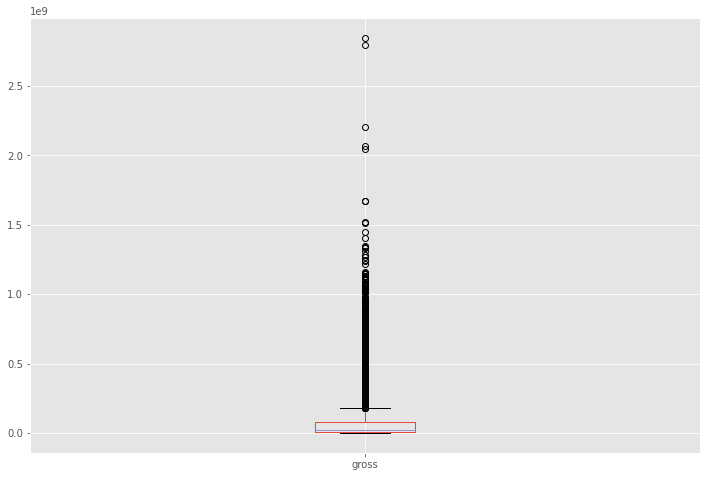

In [7]:
# Are there any Outliers?(An outlier is an observation that lies an abnormal distance
# from other values in a random sample from a population.)

movies_df.boxplot(column=['gross'])

In [8]:
# let's drop any duplicates present
movies_df.drop_duplicates()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0


In [9]:
# cleaning data as per requirement
for i in range(len(movies_df['released'])):
    if type(movies_df['released'][i])==str:
        movies_df['released'][i]=(movies_df['released'][i].split('(')[0])
    else:
        movies_df['released'][i]=movies_df['released'][i]

In [10]:
# changing data types of columns
# first we change the values of NaN and Null to 0 and then change the datatype to int
movies_df['votes']=movies_df['votes'].fillna(0)
movies_df['budget']=movies_df['budget'].fillna(0)
movies_df['gross']=movies_df['gross'].fillna(0)
movies_df['runtime']=movies_df['runtime'].fillna(0)

In [11]:
movies_df['votes']=movies_df['votes'].astype(int)
movies_df['budget']=movies_df['budget'].astype(int)
movies_df['gross']=movies_df['gross'].astype(int)
movies_df['runtime']=movies_df['runtime'].astype(int)

In [12]:
# Order our Data to get good insights

movies_df.sort_values(by=['gross'], inplace=False, ascending=False)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015",7.8,876000,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018",8.4,897000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149
7480,The Lion King,PG,Animation,2019,"July 19, 2019",6.9,222000,Jon Favreau,Jeff Nathanson,Donald Glover,United States,260000000,1670727580,Walt Disney Pictures,118
6653,Jurassic World,PG-13,Action,2015,"June 12, 2015",7.0,593000,Colin Trevorrow,Rick Jaffa,Chris Pratt,United States,150000000,1670516444,Universal Pictures,124
6043,The Avengers,PG-13,Action,2012,"May 4, 2012",8.0,1300000,Joss Whedon,Joss Whedon,Robert Downey Jr.,United States,220000000,1518815515,Marvel Studios,143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5033,Loving Annabelle,Not Rated,Drama,2006,"May 24, 2007",6.3,12000,Katherine Brooks,Katherine Brooks,Erin Kelly,United States,1000000,0,Big Easy Pictures,77
7667,Tee em el,NaN,Horror,2020,"August 19, 2020",5.7,7,Pereko Mosia,Pereko Mosia,Siyabonga Mabaso,South Africa,0,0,PK 65 Films,102
3045,Titanic,PG-13,Drama,1997,"December 19, 1997",7.8,1100000,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,-2147483648,Twentieth Century Fox,194
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019",8.4,903000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,-2147483648,Marvel Studios,181


In [13]:
# not restricted to limited rows
pd.set_option('display.max_rows',None)

In [14]:
# Assume: High Budget and gross correlation.


In [15]:
# setting negative gross values to 0 for better understanding of plot
for i in range(len(movies_df['gross'])):
    if movies_df['gross'][i]>0:
        movies_df['gross'][i]=movies_df['gross'][i]
    else:
        movies_df['gross'][i]=0

<function matplotlib.pyplot.show(close=None, block=None)>

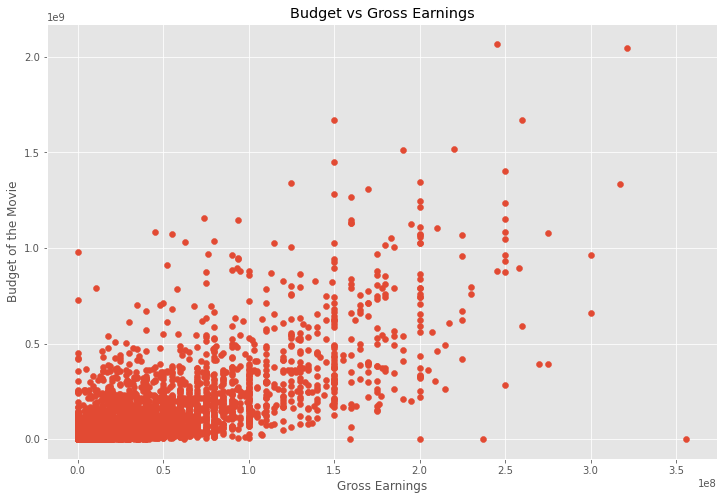

In [16]:
#scatter plot budget vs gross

plt.scatter(x=movies_df['budget'],y=movies_df['gross'])
plt.title('Budget vs Gross Earnings')
plt.xlabel('Gross Earnings')
plt.ylabel('Budget of the Movie')

plt.show

<AxesSubplot:xlabel='budget', ylabel='gross'>

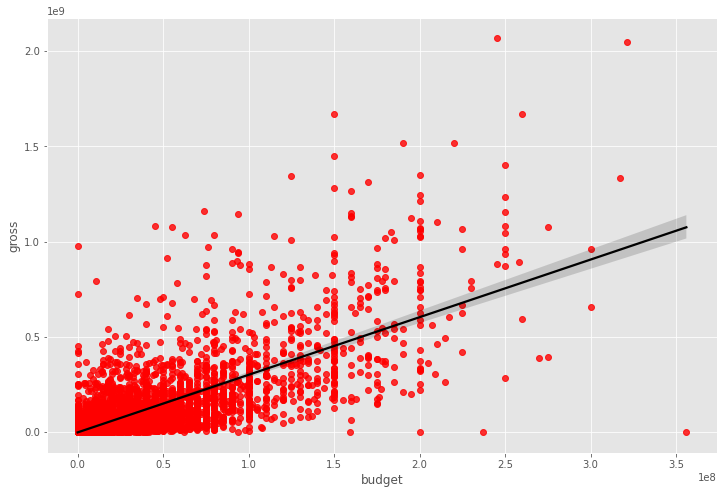

In [17]:
sns.regplot(x='budget', y='gross', data= movies_df, scatter_kws={'color':'red'}, line_kws={'color':'black'})

In [18]:
# Correlation Matrix between all numeric columns

movies_df.corr(method ='pearson')

,year,score,votes,budget,gross,runtime
year,1.000000,0.097995,0.222427,0.309212,0.270113,0.116358
score,0.097995,1.000000,0.409182,0.055665,0.184929,0.398387
votes,0.222427,0.409182,1.000000,0.486931,0.627405,0.306984
budget,0.309212,0.055665,0.486931,1.000000,0.747117,0.268372
gross,0.270113,0.184929,0.627405,0.747117,1.000000,0.232144
runtime,0.116358,0.398387,0.306984,0.268372,0.232144,1.000000


In [19]:
movies_df.corr(method ='kendall')

,year,score,votes,budget,gross,runtime
year,1.000000,0.067652,0.330410,0.209304,0.215960,0.096390
score,0.067652,1.000000,0.300115,-0.005194,0.089174,0.283966
votes,0.330410,0.300115,1.000000,0.439883,0.558922,0.197697
budget,0.209304,-0.005194,0.439883,1.000000,0.540352,0.176184
gross,0.215960,0.089174,0.558922,0.540352,1.000000,0.175893
runtime,0.096390,0.283966,0.197697,0.176184,0.175893,1.000000


In [20]:
movies_df.corr(method ='spearman')

,year,score,votes,budget,gross,runtime
year,1.000000,0.099045,0.468107,0.291152,0.313743,0.141805
score,0.099045,1.000000,0.428138,-0.007500,0.130428,0.400394
votes,0.468107,0.428138,1.000000,0.604693,0.750279,0.289359
budget,0.291152,-0.007500,0.604693,1.000000,0.714503,0.246941
gross,0.313743,0.130428,0.750279,0.714503,1.000000,0.255205
runtime,0.141805,0.400394,0.289359,0.246941,0.255205,1.000000


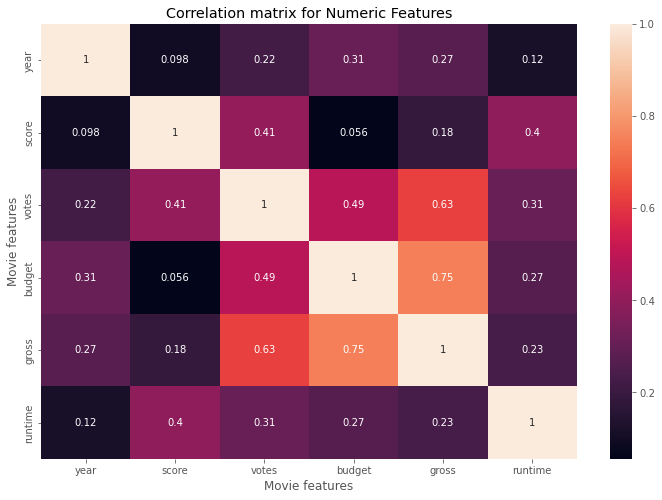

In [21]:
correlation_matrix = movies_df.corr()

sns.heatmap(correlation_matrix, annot = True)

plt.title("Correlation matrix for Numeric Features")

plt.xlabel("Movie features")

plt.ylabel("Movie features")

plt.show()

In [22]:
# Hence, we can see high correlation between Budget and Gross. As per our First assumption we were right.

In [23]:
# Using factorize - this assigns a random numeric value for each unique categorical value

movies_df.apply(lambda x: x.factorize()[0]).corr(method='pearson')

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
name,1.000000,0.143938,0.036367,0.965761,0.960206,-0.046733,0.290143,0.745905,0.805211,0.731565,0.142828,0.275691,0.946360,0.591667,0.052214
rating,0.143938,1.000000,-0.086723,0.156713,0.150081,0.012595,0.098171,0.085520,0.103623,0.093116,0.000494,0.193229,0.157150,-0.028035,0.031798
genre,0.036367,-0.086723,1.000000,0.037184,0.036853,-0.002437,0.021797,0.047288,0.033688,0.038649,-0.015795,0.069445,0.039069,0.009566,0.000442
year,0.965761,0.156713,0.037184,1.000000,0.993994,-0.044981,0.314745,0.770497,0.824770,0.756400,0.140216,0.298022,0.979888,0.601571,0.053816
released,0.960206,0.150081,0.036853,0.993994,1.000000,-0.045382,0.304628,0.769387,0.821186,0.753962,0.146635,0.289433,0.976904,0.604173,0.048459
score,-0.046733,0.012595,-0.002437,-0.044981,-0.045382,1.000000,-0.012384,-0.022687,-0.034685,-0.009896,0.023097,-0.011749,-0.047072,-0.028432,0.027432
votes,0.290143,0.098171,0.021797,0.314745,0.304628,-0.012384,1.000000,0.193607,0.226902,0.182881,-0.046388,0.395999,0.281526,0.009028,0.109088
director,0.745905,0.085520,0.047288,0.770497,0.769387,-0.022687,0.193607,1.000000,0.748340,0.682385,0.155471,0.108033,0.750931,0.552258,-0.007714
writer,0.805211,0.103623,0.033688,0.824770,0.821186,-0.034685,0.226902,0.748340,1.000000,0.675685,0.157202,0.186680,0.805629,0.546151,0.035108
star,0.731565,0.093116,0.038649,0.756400,0.753962,-0.009896,0.182881,0.682385,0.675685,1.000000,0.182045,0.110870,0.735460,0.527116,0.039567


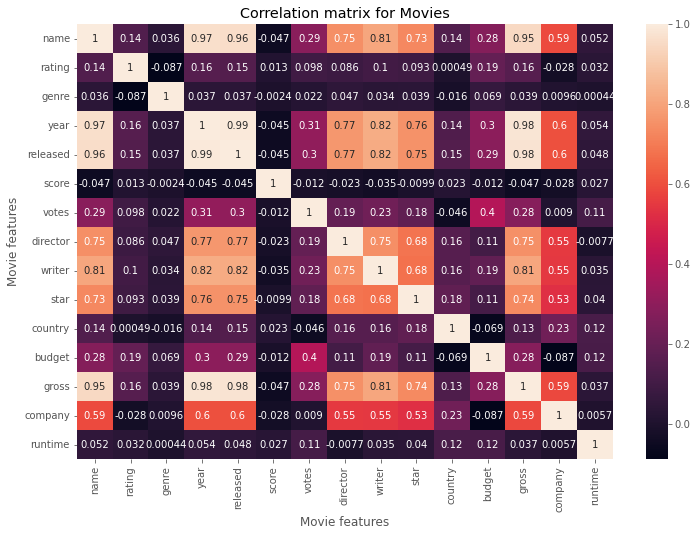

In [24]:
correlation_matrix = movies_df.apply(lambda x: x.factorize()[0]).corr(method='pearson')

sns.heatmap(correlation_matrix, annot = True)

plt.title("Correlation matrix for Movies")

plt.xlabel("Movie features")

plt.ylabel("Movie features")

plt.show()

In [25]:
correlation_mat = movies_df.apply(lambda x: x.factorize()[0]).corr()

corr_pairs = correlation_mat.unstack()

print(corr_pairs)

name      name        1.000000
          rating      0.143938
          genre       0.036367
          year        0.965761
          released    0.960206
          score      -0.046733
          votes       0.290143
          director    0.745905
          writer      0.805211
          star        0.731565
          country     0.142828
          budget      0.275691
          gross       0.946360
          company     0.591667
          runtime     0.052214
rating    name        0.143938
          rating      1.000000
          genre      -0.086723
          year        0.156713
          released    0.150081
          score       0.012595
          votes       0.098171
          director    0.085520
          writer      0.103623
          star        0.093116
          country     0.000494
          budget      0.193229
          gross       0.157150
          company    -0.028035
          runtime     0.031798
genre     name        0.036367
          rating     -0.086723
        

In [26]:
sorted_pairs = corr_pairs.sort_values(kind="quicksort")

print(sorted_pairs)

budget    company    -0.087285
company   budget     -0.087285
genre     rating     -0.086723
rating    genre      -0.086723
budget    country    -0.068884
country   budget     -0.068884
gross     score      -0.047072
score     gross      -0.047072
          name       -0.046733
name      score      -0.046733
votes     country    -0.046388
country   votes      -0.046388
released  score      -0.045382
score     released   -0.045382
year      score      -0.044981
score     year       -0.044981
          writer     -0.034685
writer    score      -0.034685
score     company    -0.028432
company   score      -0.028432
rating    company    -0.028035
company   rating     -0.028035
director  score      -0.022687
score     director   -0.022687
country   genre      -0.015795
genre     country    -0.015795
votes     score      -0.012384
score     votes      -0.012384
budget    score      -0.011749
score     budget     -0.011749
star      score      -0.009896
score     star       -0.009896
director

In [27]:
# We can now take a look at the ones that have a high correlation (> 0.5)

strong_pairs = sorted_pairs[abs(sorted_pairs) > 0.5]

print(strong_pairs)

star      company     0.527116
company   star        0.527116
          writer      0.546151
writer    company     0.546151
director  company     0.552258
company   director    0.552258
gross     company     0.588008
company   gross       0.588008
          name        0.591667
name      company     0.591667
year      company     0.601571
company   year        0.601571
released  company     0.604173
company   released    0.604173
writer    star        0.675685
star      writer      0.675685
director  star        0.682385
star      director    0.682385
name      star        0.731565
star      name        0.731565
gross     star        0.735460
star      gross       0.735460
director  name        0.745905
name      director    0.745905
writer    director    0.748340
director  writer      0.748340
gross     director    0.750931
director  gross       0.750931
released  star        0.753962
star      released    0.753962
year      star        0.756400
star      year        0.756400
released

In [28]:
# Looking at the top 15 compaies by gross revenue

CompanyGrossSum = movies_df.groupby('company')[["gross"]].sum()

CompanyGrossSumSorted = CompanyGrossSum.sort_values('gross', ascending = False)[:15]

CompanyGrossSumSorted = CompanyGrossSumSorted['gross'].astype('int64') 

CompanyGrossSumSorted

company
Warner Bros.                 56491421806
Universal Pictures           52514188890
Columbia Pictures            43008941346
Paramount Pictures           40493607415
Walt Disney Pictures         36327887792
Twentieth Century Fox        35208160390
New Line Cinema              19883797684
Marvel Studios               12268091083
DreamWorks Animation         11873612858
Touchstone Pictures          11795832638
Dreamworks Pictures          11635441081
Metro-Goldwyn-Mayer (MGM)     9230230105
Summit Entertainment          8373718838
Pixar Animation Studios       7886344526
Fox 2000 Pictures             7443502667
Name: gross, dtype: int64

In [29]:
movies_df.groupby(['company', 'year'])[["gross"]].sum()

gross
company                                            year              
"DIA" Productions GmbH & Co. KG                    2003  4.435093e+07
"Weathering With You" Film Partners                2019  1.934575e+08
.406 Production                                    1996  1.058000e+04
1+2 Seisaku Iinkai                                 2000  1.196218e+06
10 West Studios                                    2010  8.149060e+05
120 Films                                          2002  6.479328e+06
120dB Films                                        2009  2.667600e+04
                                                   2016  3.683720e+05
13 Productions                                     2000  2.546100e+04
1492 Pictures                                      1996  1.298324e+08
                                                   1999  8.742386e+07
1818 Productions                                   1983  1.223263e+07
19 Entertainment                                   2003  4.928883e+06
1978 Films                                         2017  4.065640e+07
1984 Private Defense Contractors                   2014  5.883438e+07
1992 Number Four Limited Partnership               1995  4.686937e+06
2 Loop Films                                       2002  2.643490e+05
2.0 Entertainment                                  2019  1.228104e+08
2.4.7. Films                                       2007  2.278398e+07
2003 Productions                                   2004  6.942439e+07
20th Century Studios                               2020  1.111055e+08
21 Laps Entertainment                              2014  4.129632e+07
                                                   2018  4.114238e+07
21st Century Film Corporation                      1989  3.953745e+06
                                                   1990  7.658401e+06
21st Century Films                                 1994  1.702394e+06
25th Hour Productions                              2002  2.393206e+07
26 Films                                           2009  2.045887e+07
2929 Productions                                   2007  7.248490e+06
                                                   2008  2.870518e+07
                                                   2014  5.092129e+06
2DUX²                                              2016  6.781500e+05
                                                   2018  1.977444e+08
3 Arts Entertainment                               1996  6.020933e+07
                                                   1997  7.581243e+07
                                                   2001  7.118650e+07
                                                   2010  6.496260e+05
                                                   2013  3.909596e+06
                                                   2014  1.614593e+08
                                                   2015  3.660674e+07
                                                   2019  2.238656e+07
3 Miles Apart Productions Ltd.                     1999  8.408835e+06
3311 Productions                                   2013  3.114953e+06
                                                   2017  5.042014e+06
360 Pictures                                       2007  9.669758e+06
391 Productions                                    1998  1.960216e+06
                                                   1999  9.244200e+04
3B Productions                                     1999  0.000000e+00
                                                   2003  1.679990e+05
3Mark Entertainment                                2001  4.760014e+06
4 1/2 Film                                         2006  1.297260e+06
4 Kids Entertainment                               1999  1.339493e+08
40 Acres & A Mule Filmworks                        1986  7.137502e+06
                                                   1989  3.729544e+07
                                                   1995  1.540344e+07
                                                   1999  3.457378e+07
    

In [30]:
df_numerized = movies_df


for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name]= df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes
        
df_numerized

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,6587,6,6,1980,1510,8.4,927000,2589,4014,1047,54,19000000,46998772,2319,146
1,5573,6,1,1980,1311,5.8,65000,2269,1632,327,55,4500000,58853106,731,104
2,5142,4,0,1980,1568,8.7,1200000,1111,2567,1745,55,18000000,538375067,1540,124
3,286,4,4,1980,1311,7.7,221000,1301,2000,2246,55,3500000,83453539,1812,88
4,1027,6,4,1980,1360,7.3,108000,1054,521,410,55,6000000,39846344,1777,98
5,2109,6,10,1980,2197,6.4,123000,2528,4362,241,55,550000,39754601,1812,95
6,5574,6,0,1980,1568,7.9,188000,1412,838,1277,55,27000000,115229890,2281,133
7,4436,6,3,1980,613,8.2,330000,1829,1769,2240,55,18000000,23402427,631,129
8,5281,4,0,1980,1552,6.8,101000,2306,1979,877,55,54000000,108185706,883,127
9,6213,6,3,1980,2009,7.0,10000,2864,423,589,55,10000000,15795189,2272,100


In [31]:
df_numerized.corr(method='pearson')

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
name,1.000000,-0.008069,0.016355,0.011453,-0.011223,0.017097,0.013038,0.009079,0.009081,0.006472,-0.010737,0.020548,0.011697,0.009211,0.008483
rating,-0.008069,1.000000,0.072423,0.008779,0.015735,-0.001314,0.033743,0.019483,-0.005921,0.013405,0.081244,-0.081939,-0.099630,-0.032943,0.064133
genre,0.016355,0.072423,1.000000,-0.081261,0.029039,0.027965,-0.145296,-0.015258,0.006567,-0.005477,-0.037615,-0.334021,-0.241635,-0.071067,-0.052914
year,0.011453,0.008779,-0.081261,1.000000,-0.000832,0.097995,0.222427,-0.020795,-0.008656,-0.027242,-0.070938,0.309212,0.270113,-0.010431,0.116358
released,-0.011223,0.015735,0.029039,-0.000832,1.000000,0.042918,0.016892,-0.001275,-0.002421,0.015597,-0.020063,0.010643,0.009979,-0.009933,0.005002
score,0.017097,-0.001314,0.027965,0.097995,0.042918,1.000000,0.409182,0.009559,0.019416,-0.001609,-0.133348,0.055665,0.184929,0.001030,0.398387
votes,0.013038,0.033743,-0.145296,0.222427,0.016892,0.409182,1.000000,0.000349,0.001127,-0.019146,0.073525,0.486931,0.627405,0.133457,0.306984
director,0.009079,0.019483,-0.015258,-0.020795,-0.001275,0.009559,0.000349,1.000000,0.299067,0.039234,0.017490,0.004976,-0.010192,0.004404,0.017062
writer,0.009081,-0.005921,0.006567,-0.008656,-0.002421,0.019416,0.001127,0.299067,1.000000,0.027245,0.015343,-0.025911,-0.019745,0.005646,-0.004036
star,0.006472,0.013405,-0.005477,-0.027242,0.015597,-0.001609,-0.019146,0.039234,0.027245,1.000000,-0.012998,-0.019952,-0.006731,0.012442,0.009418


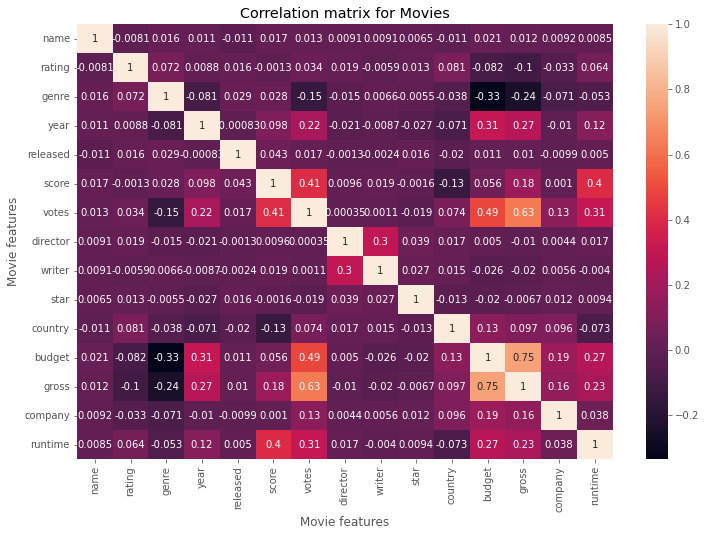

In [32]:
correlation_matrix = df_numerized.corr(method='pearson')

sns.heatmap(correlation_matrix, annot = True)

plt.title("Correlation matrix for Movies")

plt.xlabel("Movie features")

plt.ylabel("Movie features")

plt.show()

In [36]:
correlation_mat1 = df_numerized.corr()

corr_pairs1 = correlation_mat1.unstack()

print(corr_pairs1)

name      name        1.000000
          rating     -0.008069
          genre       0.016355
          year        0.011453
          released   -0.011223
          score       0.017097
          votes       0.013038
          director    0.009079
          writer      0.009081
          star        0.006472
          country    -0.010737
          budget      0.020548
          gross       0.011697
          company     0.009211
          runtime     0.008483
rating    name       -0.008069
          rating      1.000000
          genre       0.072423
          year        0.008779
          released    0.015735
          score      -0.001314
          votes       0.033743
          director    0.019483
          writer     -0.005921
          star        0.013405
          country     0.081244
          budget     -0.081939
          gross      -0.099630
          company    -0.032943
          runtime     0.064133
genre     name        0.016355
          rating      0.072423
        

In [38]:
sorted_pairs1=corr_pairs1.sort_values()
sorted_pairs1

genre     budget     -0.334021
budget    genre      -0.334021
genre     gross      -0.241635
gross     genre      -0.241635
genre     votes      -0.145296
votes     genre      -0.145296
country   score      -0.133348
score     country    -0.133348
rating    gross      -0.099630
gross     rating     -0.099630
budget    rating     -0.081939
rating    budget     -0.081939
genre     year       -0.081261
year      genre      -0.081261
country   runtime    -0.073319
runtime   country    -0.073319
genre     company    -0.071067
company   genre      -0.071067
country   year       -0.070938
year      country    -0.070938
genre     runtime    -0.052914
runtime   genre      -0.052914
genre     country    -0.037615
country   genre      -0.037615
rating    company    -0.032943
company   rating     -0.032943
star      year       -0.027242
year      star       -0.027242
budget    writer     -0.025911
writer    budget     -0.025911
year      director   -0.020795
director  year       -0.020795
country 

In [44]:
good_corr=sorted_pairs1[(sorted_pairs1)>0.5]

In [47]:
good_corr[(sorted_pairs1)!=1]

gross   votes     0.627405
votes   gross     0.627405
budget  gross     0.747117
gross   budget    0.747117
dtype: float64

In [48]:
# here we can clearly see that votes and budget have the highest correlation to gross earnings

<AxesSubplot:xlabel='rating', ylabel='gross'>

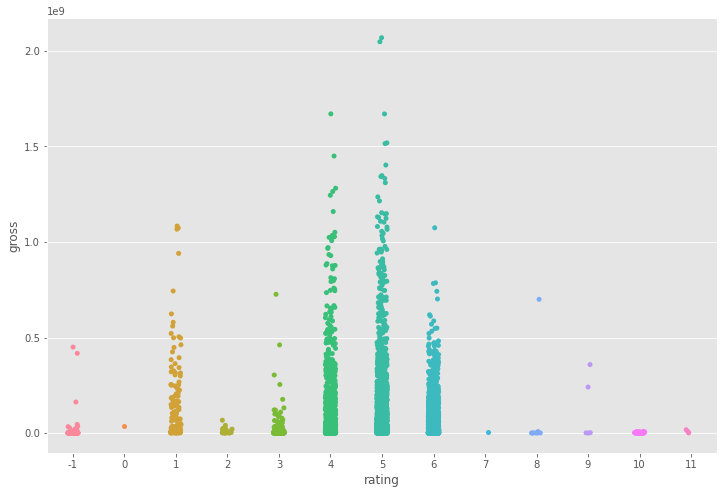

In [49]:
sns.stripplot(x="rating", y="gross", data=movies_df)